#### Preprocessing code

Code to convert MATLAB processing into Python

Created for dlx56_mPFC_1p_SohalLab repo
based off code in ruleshifting-inscopix private repo

#### Import packages


In [1]:
from __future__ import annotations
import os
from pathlib import Path
from datetime import datetime
from typing import List, Any, Dict
import numpy as np
import pandas as pd
import notebook_setup
info = notebook_setup.setup()
# set up plotting code
import matplotlib as matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
# Apply mplstyle via absolute path from setup info
style_path = Path(info["function_py_storage"]) / "paper_plot.mplstyle"
print(f"Loading style guide at {style_path}")
if style_path.is_file():
    plt.style.use(str(style_path))
else:
    print(f"[warn] Style not found at: {style_path}")
from concurrent.futures import ProcessPoolExecutor, as_completed

Loading style guide at c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\paper_plot.mplstyle


In [2]:
#import local yaml for env preset variables
from analysis_config_loader import load_analysis_config  # new import
config_path = "analysis_config.yaml"  # adjust as needed
analysis_config = load_analysis_config(config_path)

In [3]:
analysis_config

AnalysisConfig(trial_section_names=['pre_outcome', 'post_outcome', 'ITI'], phase_division_types=['simple', 'complex'], task_phase_names=['Early_IA_Error', 'Early_IA_Correct', 'Late_IA', 'Early_RS_Error', 'Early_RS_Correct', 'Late_RS'], simple_phase_names=['IA_Error', 'IA_Correct', 'RS_Error', 'RS_Correct'], feature_type_names=['correct_error', 'IA_RS', 'task_phase'], phase_is_solo_vector=True, shuffle_to_use='circle', num_shuffles=1000, early_division_criteria_types=['count', 'first_2'], early_criteria_type='count', early_criteria_value=5, trial_section_divisions=[], corr_vector_is_triangular=True, seconds_before_post_to_keep=5, time_series_bin_size=0.25, corr_time_series_bin_size=0.5, percentile=95, threshold_with_shuffle=True, min_baseline_len=12000, final_thresh=2.5, final_thresh2=12.5, final_thresh3=20, final_thresh4_abs=0.01, drop_low_value_peak_events=False, drop_low_act_cell_in_dataset_obj=False, low_act_thresh_in_obj_init=0.005, cutoff_filter='bimodality', peak_event_cutoff_per

#### Define dataset methods

In [5]:
#set parameters
data_type_used = "calcium_spikes" #OR, 'dff'
run_activity_enrichment = True
export_mean_active = True
use_WT_CLNZ_folder = False
phase_type = analysis_config.phase_division_types[1]  # 'complex', early vs late and correct vs error
print(phase_type)
# set up locations for input/output #get where to load data 
root_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\code')
print(root_dir)
os.chdir(root_dir)
data_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data')

#make analysis folder 
hour_str = datetime.now().strftime("%H")

storage_folder_name = root_dir / Path(f"processed_{data_type_used}")
print(storage_folder_name)
storage_folder_name.mkdir(parents=True, exist_ok=True)


complex
c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code
c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\processed_calcium_spikes


In [ ]:
# ---------- Project specific hooks (unchanged stubs) ----------

def return_binary_activity_vec_sig_active_in_task_stage(dataset_object: DatasetObject) -> pd.DataFrame:
    raise NotImplementedError

In [ ]:
def check_corrupted_files(failed_files):
    # Optional Investigate corrupted files
    print("="*70)
    print("INVESTIGATING CORRUPTED FILES")
    print("="*70)

    if len(failed_files) == 0:
        print("No failed files to investigate.")
        return
    
    for fname in failed_files:
        filepath = source_dataset_location / fname
        
        print(f"\n📁 {fname}")
        print("-" * 70)
        
        if not filepath.exists():
            print("  ❌ File does not exist!")
            continue
        
        # Check file size
        size_bytes = filepath.stat().st_size
        size_kb = size_bytes / 1024
        size_mb = size_kb / 1024
        
        print(f"  Size: {size_bytes:,} bytes ({size_mb:.2f} MB)")
        
        # Read first bytes to check file signature
        with open(filepath, 'rb') as f:
            header = f.read(100)
        
        # Check for MATLAB file signatures
        print(f"  First 20 bytes (hex): {header[:20].hex()}")
        
        # HDF5 files should start with \x89HDF\r\n\x1a\n
        if header[:4] == b'\x89HDF':
            print("  ✓ Valid HDF5 signature")
        elif header[:4] == b'MATL':
            print("  ⚠️ Old MATLAB format (v5/v6) - needs scipy.io")
        else:
            print(f"  ❌ Unknown file signature - file may be corrupted")
            print(f"     Expected: b'\\x89HDF' or b'MATL'")
            print(f"     Got: {header[:4]}")
        
        # Try to detect if file is truncated
        if size_mb < 1:
            print(f"  ⚠️ WARNING: File is unusually small ({size_mb:.2f} MB)")

    # Compare with a working file
    print("\n" + "="*70)
    print("COMPARISON WITH WORKING FILES")
    print("="*70)

    # Get file sizes of all working files
    working_sizes = []
    for obj in loaded_objects[:5]:
        fname = obj['name'] + '_dataset_object.mat'
        fpath = source_dataset_location / fname
        if fpath.exists():
            size_mb = fpath.stat().st_size / 1024 / 1024
            working_sizes.append(size_mb)
            print(f"  {fname}: {size_mb:.2f} MB")

    if working_sizes:
        avg_size = sum(working_sizes) / len(working_sizes)
        print(f"\n  Average working file size: {avg_size:.2f} MB")


INVESTIGATING CORRUPTED FILES

COMPARISON WITH WORKING FILES
  10_3_HET_RS1_dataset_object.mat: 103.34 MB
  10_3_HET_RS2_dataset_object.mat: 68.89 MB
  10_3_HET_RS3_dataset_object.mat: 75.41 MB
  13_3_HET_RS1_dataset_object.mat: 142.80 MB
  13_3_HET_RS2_dataset_object.mat: 71.08 MB

  Average working file size: 92.30 MB


In [7]:
#get all dataset names

#verify you are using the correct number of dataset 
source_dataset_location = Path(r"C:\Users\13car\Dropbox\UCSF\vikaas\Ruleshifting task notes\dlx mice notes\All datasets- Padded Labels, raster, EXTRACT outputs\dataset_objects")


content_names = [f for f in source_dataset_location.glob('**/*') if "object" in f.name]
print(f"Found {len(content_names)} files in {source_dataset_location}")
for file in content_names:
    print(file.name)

assert len(content_names) == 35, "Number of datasets does not match"

Found 35 files in C:\Users\13car\Dropbox\UCSF\vikaas\Ruleshifting task notes\dlx mice notes\All datasets- Padded Labels, raster, EXTRACT outputs\dataset_objects
10_3_HET_RS1_dataset_object.mat
10_3_HET_RS2_dataset_object.mat
10_3_HET_RS3_dataset_object.mat
13_3_HET_RS1_dataset_object.mat
13_3_HET_RS2_dataset_object.mat
13_3_HET_RS3_dataset_object.mat
13_4_WT_RS1_dataset_object.mat
13_4_WT_RS2_dataset_object.mat
13_5_HET_RS1_dataset_object.mat
13_5_HET_RS2_dataset_object.mat
13_5_HET_RS3_dataset_object.mat
13_6_WT_RS1_dataset_object.mat
13_6_WT_RS2_dataset_object.mat
13_8_HET_RS1_dataset_object.mat
13_8_HET_RS2_dataset_object.mat
13_8_HET_RS3_dataset_object.mat
14_2_WT_RS1_dataset_object.mat
14_2_WT_RS2_dataset_object.mat
15_1_HET_RS1_dataset_object.mat
15_1_HET_RS2_dataset_object.mat
15_1_HET_RS3_dataset_object.mat
5_3_WT_RS1_dataset_object.mat
5_3_WT_RS2_dataset_object.mat
6_2_WT_RS1_dataset_object.mat
6_2_WT_RS2_dataset_object.mat
7_2_WT_RS1_dataset_object.mat
7_4_WT_RS1_dataset_obje

In [ ]:
import h5py

def load_matlab_object(filepath):
    """Load MATLAB dataset_with_spatial_ROI object from .mat file"""
    # Parse metadata from filename
    filename = filepath.stem.replace('_dataset_object', '')
    parts = filename.split('_')
    
    # Extract name, geno from filename (e.g., "10_3_HET_RS1")
    name = filename
    if len(parts) >= 3:
        geno = parts[2]  # HET or WT
        session = parts[3] if len(parts) > 3 else 'RS1'
    else:
        geno = "UNKNOWN"
        session = "RS1"
    
    try:
        with h5py.File(filepath, 'r') as f:            # Load numeric data from known datasets
            raster = f['#refs#']['i'][()]  # (time, cells)
            # Get deduplicated flag from group x
            deduplicated = f['#refs#']['x']['deduplicated'][0, 0] if 'deduplicated' in f['#refs#']['x'] else False
            # Create object dictionary
            obj = {
                'name': name,
                'geno': geno,
                'session': session,
                'geno_day': None,  # Will need to be set externally if needed
                'raster': raster.T,  # Transpose to (cells, time)
                'deduplicated': bool(deduplicated),
                'good_cells': f['#refs#']['k'][()] if 'k' in f['#refs#'] else None,  # Cell IDs
                'labels': f['#refs#']['j'][()] if 'j' in f['#refs#'] else None,  # Trial/time info
            }
            # Load spatial info if present
            if 'n' in f['#refs#']:
                spatial = f['#refs#']['n']
                obj['spatial_weights'] = spatial['spatial_weights'][()] if 'spatial_weights' in spatial else None
                obj['temporal_weights'] = spatial['temporal_weights'][()] if 'temporal_weights' in spatial else None
                obj['user_labels'] = spatial['user_labels'][()] if 'user_labels' in spatial else None
                obj['subject_name'] = spatial['subject_name'][()] if 'subject_name' in spatial else None
            
            return obj
    
    except (OSError, KeyError) as e:
        print(f"  ERROR loading {filepath.name}: {e}")
        return None


In [9]:
# Load all files with error handling
loaded_objects = []
failed_files = []

for num, file in enumerate(content_names):
    print(f"Loading file {num}/{len(content_names)}: {file.name}")
    
    obj = load_matlab_object(file)
    
    if obj is None:
        failed_files.append(file.name)
        print(f"  SKIPPED\n")
        continue
    
    loaded_objects.append(obj)
    print(f"  ✓ {obj['name']}: {obj['raster'].shape[0]} cells × {obj['raster'].shape[1]} timepoints\n")

print("\n" + "="*60)
print(f"SUMMARY: Successfully loaded {len(loaded_objects)}/{len(content_names)} files")
if failed_files:
    print(f"\n Failed files ({len(failed_files)}):")
    for fname in failed_files:
        print(f"  - {fname}")


Loading file 0/35: 10_3_HET_RS1_dataset_object.mat
  ✓ 10_3_HET_RS1: 136 cells × 150415 timepoints

Loading file 1/35: 10_3_HET_RS2_dataset_object.mat
  ✓ 10_3_HET_RS2: 168 cells × 97940 timepoints

Loading file 2/35: 10_3_HET_RS3_dataset_object.mat
  ✓ 10_3_HET_RS3: 157 cells × 108794 timepoints

Loading file 3/35: 13_3_HET_RS1_dataset_object.mat
  ✓ 13_3_HET_RS1: 160 cells × 191533 timepoints

Loading file 4/35: 13_3_HET_RS2_dataset_object.mat
  ✓ 13_3_HET_RS2: 145 cells × 108651 timepoints

Loading file 5/35: 13_3_HET_RS3_dataset_object.mat
  ✓ 13_3_HET_RS3: 147 cells × 128277 timepoints

Loading file 6/35: 13_4_WT_RS1_dataset_object.mat
  ✓ 13_4_WT_RS1: 183 cells × 153831 timepoints

Loading file 7/35: 13_4_WT_RS2_dataset_object.mat
  ✓ 13_4_WT_RS2: 171 cells × 106245 timepoints

Loading file 8/35: 13_5_HET_RS1_dataset_object.mat
  ✓ 13_5_HET_RS1: 120 cells × 229350 timepoints

Loading file 9/35: 13_5_HET_RS2_dataset_object.mat
  ✓ 13_5_HET_RS2: 125 cells × 141283 timepoints

Loadi

In [11]:
# Try loading the old-format MATLAB files with scipy.io
import scipy.io

def load_matlab_object_scipy(filepath):
    """Load old-format MATLAB files using scipy.io"""
    
    # Parse metadata from filename
    filename = filepath.stem.replace('_dataset_object', '')
    parts = filename.split('_')
    
    name = filename
    if len(parts) >= 3:
        geno = parts[2]
        session = parts[3] if len(parts) > 3 else 'RS1'
    else:
        geno = "UNKNOWN"
        session = "RS1"
    
    try:
        # Load with scipy
        mat_data = scipy.io.loadmat(filepath, struct_as_record=False, squeeze_me=True)
        
        # Extract the dataset_object
        if 'dataset_object' in mat_data:
            ds_obj = mat_data['dataset_object']
            
            # Access object properties
            obj = {
                'name': name,
                'geno': geno,
                'session': session,
                'geno_day': None,
                'raster': ds_obj.raster.T if hasattr(ds_obj, 'raster') else None,
                'deduplicated': bool(ds_obj.deduplicated) if hasattr(ds_obj, 'deduplicated') else False,
                'good_cells': ds_obj.good_cells if hasattr(ds_obj, 'good_cells') else None,
                'labels': ds_obj.labels if hasattr(ds_obj, 'labels') else None,
            }
            
            return obj
        else:
            print(f"  ⚠️ 'dataset_object' not found in {filepath.name}")
            print(f"     Available keys: {list(mat_data.keys())}")
            return None
            
    except Exception as e:
        print(f"  ❌ scipy.io also failed: {e}")
        return None

# Try loading the failed files with scipy.io
print("="*70)
print("ATTEMPTING TO RECOVER FILES WITH SCIPY.IO")
print("="*70)

recovered_objects = []

for fname in failed_files:
    if '9_3_HET_RS2' in fname:
        print(f"\n📁 {fname}")
        print("  ⏭️  SKIPPING - File is completely corrupted (all zeros)")
        continue
    
    print(f"\n📁 {fname}")
    filepath = source_dataset_location / fname
    
    obj = load_matlab_object_scipy(filepath)
    
    if obj is not None and obj['raster'] is not None:
        print(f"  ✅ RECOVERED: {obj['raster'].shape[0]} cells × {obj['raster'].shape[1]} timepoints")
        recovered_objects.append(obj)
    else:
        print(f"  ❌ Recovery failed")

print(f"\n{'='*70}")
print(f"Recovered {len(recovered_objects)} additional files")
print(f"Total: {len(loaded_objects) + len(recovered_objects)}/35 files")


ATTEMPTING TO RECOVER FILES WITH SCIPY.IO

Recovered 0 additional files
Total: 35/35 files


<Axes: >

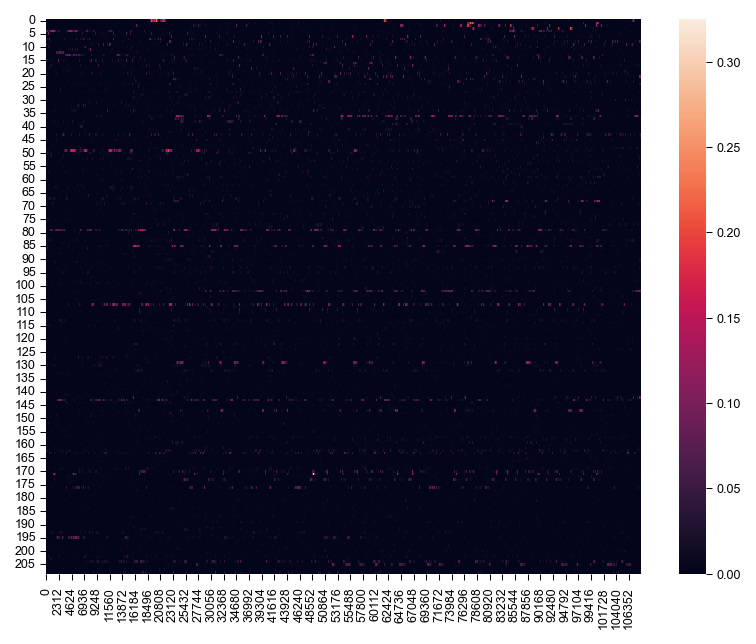

In [12]:
sns.heatmap(obj['temporal_weights'])

<Axes: >

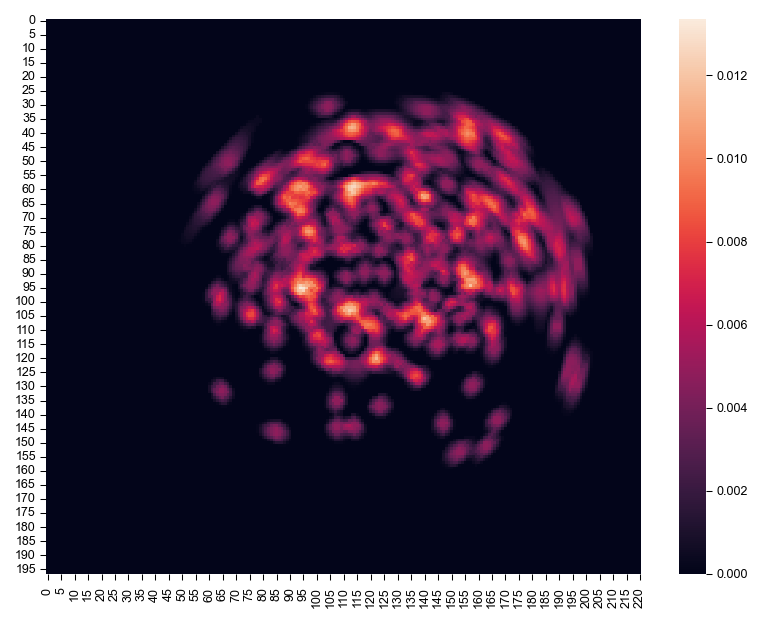

In [13]:
sns.heatmap(np.mean(obj['spatial_weights'], axis=0))

In [14]:
obj['labels']

array([[ 1.],
       [ 1.],
       [ 1.],
       ...,
       [15.],
       [15.],
       [15.]])

In [15]:
# Map the actual data by examining what's populated vs empty
file = content_names[0]
print(f"Loading: {file.name}\n")

with h5py.File(file, 'r') as f:
    print("=== POPULATED properties in group x ===")
    x_group = f['#refs#']['x']
    for prop_name in x_group.keys():
        prop = x_group[prop_name]
        is_empty = prop.attrs.get('MATLAB_empty', 0) == 1
        if not is_empty:
            val = prop[()]
            if prop.dtype == 'uint32':
                # Try to decode as string
                try:
                    str_val = ''.join(chr(c) for c in val.flatten() if c != 0)
                    print(f"{prop_name}: '{str_val}' (uint32 → string)")
                except:
                    print(f"{prop_name}: {val}")
            else:
                print(f"{prop_name}: {val}")
    
    print("\n=== EMPTY properties in group x (data stored elsewhere) ===")
    for prop_name in x_group.keys():
        prop = x_group[prop_name]
        is_empty = prop.attrs.get('MATLAB_empty', 0) == 1
        if is_empty:
            print(f"  {prop_name}")
    
    print("\n=== Likely data mappings (by shape/size) ===")
    print("\nLarge numeric datasets (probable raster/timeseries data):")
    print(f"  i: {f['#refs#']['i'].shape} {f['#refs#']['i'].dtype} → Likely main RASTER (time×cells)")
    print(f"  p: {f['#refs#']['p'].shape} {f['#refs#']['p'].dtype} → Likely processed/ROI raster")
    print(f"  j: {f['#refs#']['j'].shape} {f['#refs#']['j'].dtype} → Likely timestamps/trial vector")
    print(f"  k: {f['#refs#']['k'].shape} {f['#refs#']['k'].dtype} → Likely cell IDs/labels (136 cells)")
    
    print("\nSpatial ROI data (group n):")
    n_group = f['#refs#']['n']
    for key in n_group.keys():
        print(f"  {key}: {n_group[key].shape} {n_group[key].dtype}")
    
    print("\n=== Confirmation: Check dimensions ===")
    i_data = f['#refs#']['i']
    k_data = f['#refs#']['k']
    print(f"Dataset i has {i_data.shape[1]} cells (columns)")
    print(f"Dataset k has {k_data.shape[0]} entries (should match)")
    print(f"Match: {i_data.shape[1] == k_data.shape[0]}")


Loading: 10_3_HET_RS1_dataset_object.mat

=== POPULATED properties in group x ===
deduplicated: [[0]]
geno: [[3707764736          2          1          1          8          1]]
geno_day: [[3707764736          2          1          1          7          1]]
name: [[3707764736          2          1          1          6          1]]

=== EMPTY properties in group x (data stored elsewhere) ===
  C
  ROI_locations
  good_cells
  labels
  num_cells
  output_struct
  raster

=== Likely data mappings (by shape/size) ===

Large numeric datasets (probable raster/timeseries data):
  i: (150415, 136) float64 → Likely main RASTER (time×cells)
  p: (150415, 263) float32 → Likely processed/ROI raster
  j: (150415, 1) float64 → Likely timestamps/trial vector
  k: (136, 1) float64 → Likely cell IDs/labels (136 cells)

Spatial ROI data (group n):
  spatial_weights: (263, 197, 204) float32
  subject_name: (1, 6) uint32
  temporal_weights: (263, 150415) float32
  user_labels: (263, 1) float64

=== Confi

In [16]:
if run_activity_enrichment:
    def _job(name: str) -> pd.DataFrame:
        ds = dfm.get_dataset_object_i(dataset_folders / name, data_type_used)
        return return_binary_activity_vec_sig_active_in_task_stage(ds)

    tables: List[pd.DataFrame] = [None] * len(content_names)
    with ProcessPoolExecutor() as ex:
        futs = {ex.submit(_job, nm): i for i, nm in enumerate(content_names)}
        for fut in as_completed(futs):
            tables[futs[fut]] = fut.result()

    needed_cols = analysis_config.get_num_phase_pairs(phase_type) + 2
    fixed = []
    for df in tables:
        if df.shape[1] < needed_cols and "baseline" not in df.columns:
            df = df.copy()
            df["baseline"] = 0
        fixed.append(df)

    combined = pd.concat(fixed, axis=0, ignore_index=True)
    metadata_vec = [
        str(datetime.now()),
        analysis_config.num_shuffles,
        analysis_config.percentile,
        analysis_config.drop_low_value_peak_events,
        analysis_config.cutoff_filter,
        analysis_config.peak_event_cutoff_percentile,
    ]
    meta_df = pd.DataFrame([metadata_vec] * len(combined))
    combined = pd.concat([combined, meta_df], axis=1)

    dataset_cohort = "WT_CLNZ_" if use_WT_CLNZ_folder else "main_datasets_"
    out_name = f"{dataset_cohort}{phase_type}TACO- {data_type_used}_activity by task phase_{datetime.now().date()}.xlsx"
    combined.to_excel(out_name, index=False)

if export_mean_active:
    mean_tables: List[pd.DataFrame] = []
    for i, nm in enumerate(content_names, start=1):
        print(f"{i}/{len(content_names)} mean activity found")
        ds = dfm.get_dataset_object_i(dataset_folders / nm, data_type_used)
        curr_mean = ds.raster.mean(axis=1)
        names = np.full(curr_mean.shape[0], ds.name)
        mean_tables.append(pd.DataFrame({"curr_mean_active": curr_mean, "name_col": names}))

    activation_table = pd.concat(mean_tables, axis=0, ignore_index=True)
    out_name2 = f"{data_type_used}_mean dataset activity_{datetime.now().date()}.xlsx"
    activation_table.to_excel(out_name2, index=False)

print("Done creating all thresholded activity vectors for all datasets. Exported")


BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.